## ME2202 : Heat and Mass Transfer - Project 1 (Case 2)

#### Group Members : 
##### 2302MT03 Shourya
##### 2303ME02 Abhimanyu
##### 2303ME08 Pradyumna
##### 2303ME10 Suryashraj
##### 2303ME14 Saikumar

### Steady-state heat conduction in a square plate

### Develop a code in Matlab/Python to solve the steady-conduction in a rectangular plate of  1m x 1 m size having thermal conductivity of 10 W/m-K using finite difference method for the following : Case-2: The left and top faces are maintained at 100 C and 500 C respectively. The bottom and right faces are exposed to a fluid at 100 C having h = 10 W.m2-K. Compare the results with the nodal values provided in the book by JP Holman.Draw the isothermal contours on the plate.

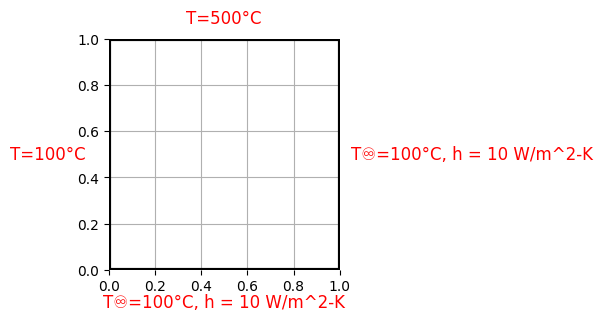

Number of Nodal Points in x/y direction :  4


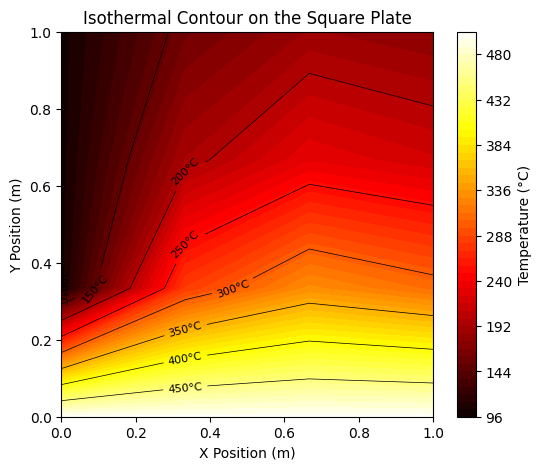

In [19]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(3, 3))

# Define square coordinates
square = [[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]]

# Plot the square
ax.plot(*zip(*square), 'k', linewidth=3)

# Labelling the boundary temperatures
ax.text(-0.1, 0.5, "T=100°C", va='center', ha='right', fontsize=12, color='red')
ax.text(1.05, 0.5, "T♾️=100°C, h = 10 W/m^2-K", va='center', ha='left', fontsize=12, color='red')
ax.text(0.5, 1.05, "T=500°C", va='bottom', ha='center', fontsize=12, color='red')
ax.text(0.5, -0.1, "T♾️=100°C, h = 10 W/m^2-K", va='top', ha='center', fontsize=12, color='red')

# Adjust plot settings
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.set_frame_on(False)
plt.grid()
# Show the plot
plt.show()

# Define plate dimensions and grid resolution
L, W = 1.0, 1.0  # Length and Width of plate (m)
nx = int(input("Number of Nodal Points in x/y direction : "))
ny = nx  # Number of grid points in x and y directions
dx, dy = L / (nx - 1), W / (ny - 1)  # Grid spacing
k = 10 # Thermal Conductivity
h = 10 # Convective Heat Transfer Coefficient

# Initialize temperature field
T_nodal = np.zeros((ny, nx))
T_amb = 100 # ambient temperature

# Apply boundary conditions
T_nodal[:, 0] = 100   # Left boundary (100°C)
T_nodal[0, :] = 500   # Top boundary (500°C)

# Solver parameters
tolerance = 1e-4  # Convergence criteria
max_iterations = 5000  # Maximum iterations

# Solve using Gauss-Seidel iteration
for iteration in range(max_iterations):
    T_old = T_nodal.copy()

    # Interior Nodes
    for i in range(1, ny-1):
        for j in range(1, nx-1):
            T_nodal[i, j] = 0.25 * (T_old[i+1, j] + T_old[i-1, j] + T_old[i, j+1] + T_old[i, j-1])

    # Convective Boundary Condition
    for i in range(1, ny-1):
        T_nodal[i, nx-1] = (1 / (dx + 2)) * (0.5 * (2 * T_old[i, nx-2] + T_old[i+1, nx-1] + T_old[i-1, nx-1]) + dx * T_amb)
        
    for j in range(1, nx-1):
        T_nodal[ny-1, j] = (1 / (dx + 2)) * (0.5 * (2 * T_old[ny-2, j] + T_old[ny-1, j+1] + T_old[ny-1, j-1]) + dx * T_amb)

    # Convective Corner Condition
    T_nodal[ny-1, nx-1] = (1 / (2 * (dx + 1))) * (2 * dx * T_amb + T_old[ny-2, nx-1] + T_old[ny-1, nx-2])
    if np.max(np.abs(T_nodal - T_old)) < tolerance:
        break

# Plot the temperature distribution
plt.figure(figsize=(6, 5))

# Create mesh grid correctly (x increases from left to right, y from top to bottom)
x = np.linspace(0, L, nx)
y = np.linspace(0, W, ny)
X, Y = np.meshgrid(x, y)

# Contour plot with temperature distribution
contour = plt.contourf(X, Y, T_nodal, cmap="hot", levels=50)
cbar = plt.colorbar(contour)
cbar.set_label("Temperature (°C)")

# Add black contour lines
contour_lines = plt.contour(X, Y, T_nodal, colors="black", linewidths=0.5)
plt.clabel(contour_lines, inline=True, fontsize=8, fmt='%1.0f°C')

# Labels and title
plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.title("Isothermal Contour on the Square Plate")
plt.show()

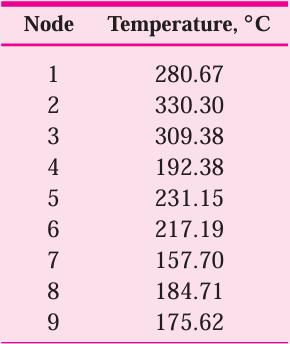

In [15]:
from IPython.display import Image
Image("jp_holman_nodal_soln_image.jpg")

In [17]:
node = 1
for i in range(1, ny):
    for j in range(1, nx):
        print("Node", node,":", T_nodal[i, j])
        node = node + 1

Node 1 : 280.7227458202152
Node 2 : 330.4214590187851
Node 3 : 309.6383355977927
Node 4 : 192.46965178986937
Node 5 : 231.32493683969466
Node 6 : 217.46953792576792
Node 7 : 157.83110668213
Node 8 : 184.9394174438402
Node 9 : 175.90328652921914
